In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import time
from sklearn.metrics import accuracy_score,f1_score, classification_report
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest



In [2]:
df = pd.read_csv('Crop_recommendation.csv')


In [ ]:
df.dtypes



,0
N,int64
P,int64
K,int64
temperature,float64
humidity,float64
ph,float64
rainfall,float64
label,object


In [ ]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


checking the equal distribution of target for more uniformity

In [ ]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


# Histogram for reference

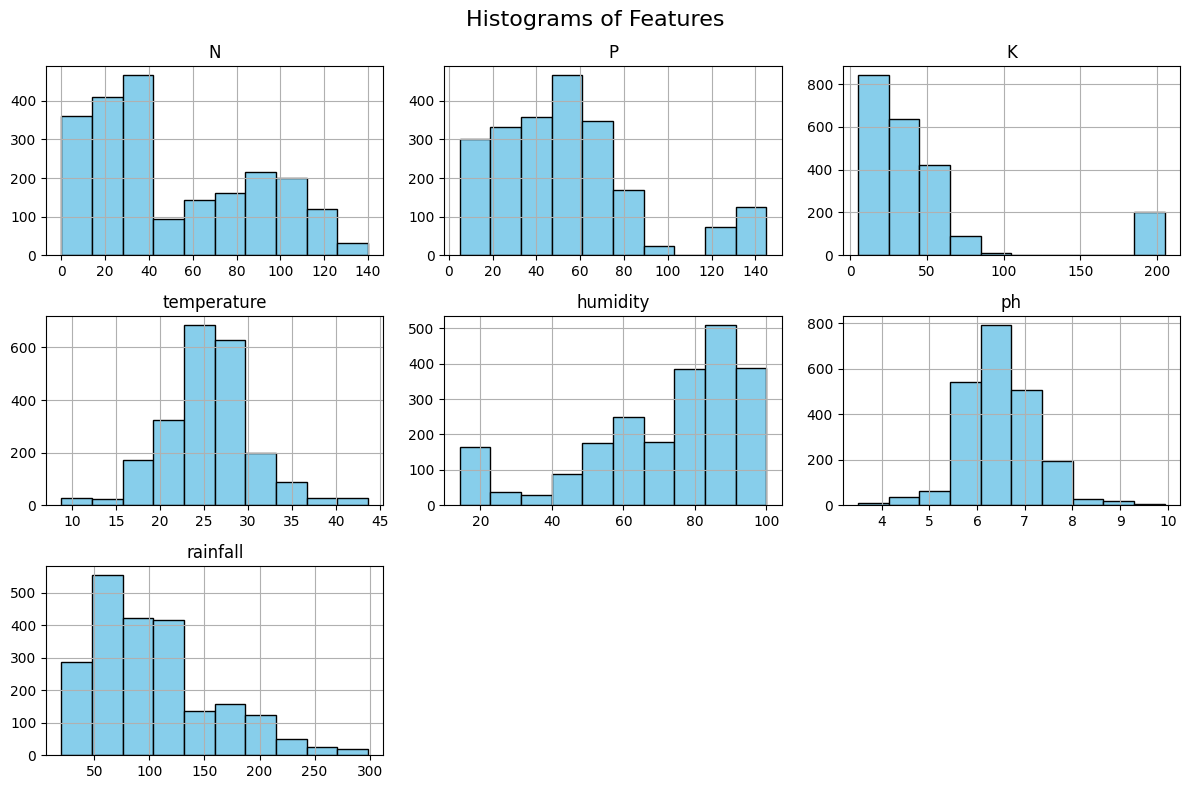

In [ ]:
df_features = df.drop('label', axis=1)

df_features.hist(figsize=(12, 8), bins=10, color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Features", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,0.642857,0.264286,0.190,0.345886,0.790267,0.466264,0.656458,rice
1,0.607143,0.378571,0.180,0.371445,0.770633,0.549480,0.741675,rice
2,0.428571,0.357143,0.195,0.406854,0.793977,0.674219,0.875710,rice
3,0.528571,0.214286,0.175,0.506901,0.768751,0.540508,0.799905,rice
4,0.557143,0.264286,0.185,0.324378,0.785626,0.641291,0.871231,rice


In [3]:
from sklearn.model_selection import train_test_split
X = df.drop('label', axis=1)
Y=df['label']
features=X.columns

x_train, x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)


In [4]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [ ]:
x_train_scaled.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [ ]:
print(x_train.shape)
print(x_test.shape)

(1540, 7)
(660, 7)


In [ ]:
f1_sc_list=[]

# Using all attributes (KNN model)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_res=knn.predict(x_test)

sc_all=f1_score(y_test,y_res,average='weighted')
f1_sc_list.append(sc_all)
print(f1_sc_list)
print(y_res[:10])
print(y_test[:10])

[0.9803103350189257]
['kidneybeans' 'mothbeans' 'blackgram' 'jute' 'jute' 'kidneybeans'
 'papaya' 'mango' 'coffee' 'maize']
381     kidneybeans
552       mothbeans
768       blackgram
2081           jute
2055           jute
363     kidneybeans
1716         papaya
1149          mango
2107         coffee
183           maize
Name: label, dtype: object


using mutual_info_classif




In [ ]:
x_train_c,x_test_c,y_train_c,y_test_c=x_train.copy(),x_test.copy(),y_train.copy(),y_test.copy()


In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import SelectKBest

f1_sc_f=[]
for k in range(1,8):
  selector=SelectKBest(mutual_info_classif,k=k)
  selector.fit(x_train_c,y_train_c)
  x_train_new=selector.transform(x_train_c)
  x_test_new=selector.transform(x_test_c)
  knn.fit(x_train_new,y_train_c)
  y_new_pred=knn.predict(x_test_new)

  f1_sc_f.append(round(f1_score(y_test_c,y_new_pred,average='weighted'),3))

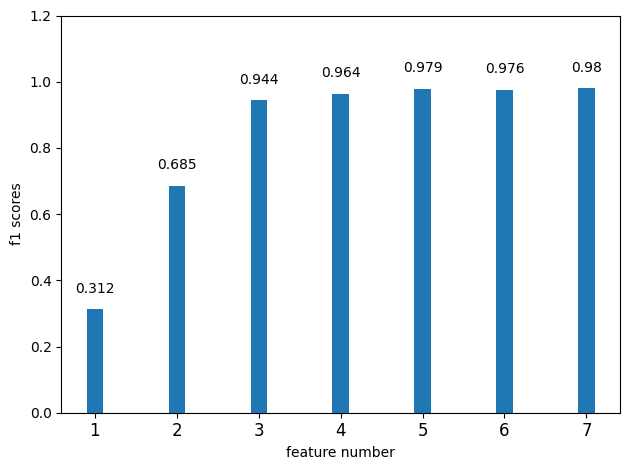

In [ ]:
fig, g=plt.subplots()
x=np.arange(1,8)
y=f1_sc_f
g.bar(x,y,width=0.2)
g.set_xlabel('feature number')
g.set_ylim(0,1.2)
g.set_ylabel('f1 scores')
g.set_xticks(np.arange(1,8))
g.set_xticklabels(np.arange(1,8),fontsize=12)
for i,v in enumerate(y):
  plt.text(x=i+1,y=v+0.05,s=str(v),ha='center')

plt.tight_layout()

In [ ]:
selector=SelectKBest(mutual_info_classif,k=7)
selector.fit(x_train_c,y_train_c)
x_train_final=selector.transform(x_train_c)
x_test_final=selector.transform(x_test_c)
knn.fit(x_train_final,y_train_c)
y_final_pred=knn.predict(x_test_final)

print(round(f1_score(y_test_c,y_final_pred,average='weighted'),3))


0.98


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test_c,y_final_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       0.91      1.00      0.95        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       0.94      1.00      0.97        30
      grapes       1.00      1.00      1.00        30
        jute       0.90      0.93      0.92        30
 kidneybeans       0.97      1.00      0.98        30
      lentil       1.00      0.93      0.97        30
       maize       1.00      0.93      0.97        30
       mango       0.94      1.00      0.97        30
   mothbeans       1.00      0.93      0.97        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00        30
      papaya       1.00    

In [ ]:
f1_sc_list.append(y_final_pred)

In [ ]:
from sklearn.metrics import accuracy_score

print(round(accuracy_score(y_test_c,y_final_pred),3))

0.98


In [ ]:
from sklearn.feature_selection import chi2

f1_score_chi2=[]

for k in range(1,8):
 selector_chi2=SelectKBest(chi2,k=k)
 selector_chi2.fit(x_train_c,y_train_c)
 x_train_chi2=selector.transform(x_train_c)
 x_test_chi2=selector.transform(x_test_c)

 knn.fit(x_train_chi2,y_train_c)
 y_pred_chi2=knn.predict(x_test_chi2)

 f1_score_chi2.append(round(f1_score(y_test_c,y_pred_chi2,average='weighted'),3))


In [ ]:
print(f1_score_chi2)

[0.98, 0.98, 0.98, 0.98, 0.98, 0.98, 0.98]


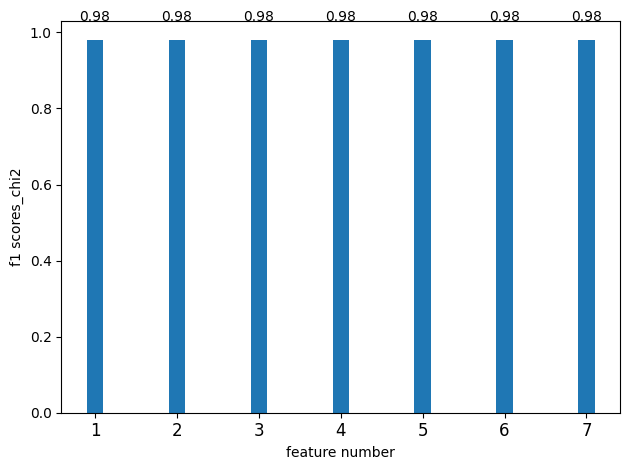

In [ ]:
fig, g=plt.subplots()
x=np.arange(1,8)
y=f1_score_chi2
g.bar(x,y,width=0.2)
g.set_xlabel('feature number')
g.set_ylim
g.set_ylabel('f1 scores_chi2')
g.set_xticks(np.arange(1,8))
g.set_xticklabels(np.arange(1,8),fontsize=12)
for i,v in enumerate(y):
  plt.text(x=i+1,y=v+0.05,s=str(v),ha='center')

plt.tight_layout()

In [ ]:
from sklearn.metrics import accuracy_score

print(round(accuracy_score(y_test_c,y_final_pred),3))

0.98


Script by chatgpt for comparison of chi2 with mutual_info_classif

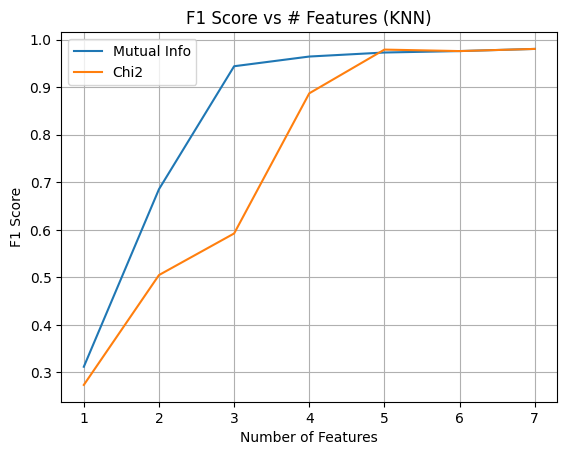

In [ ]:
f1_mi = []
f1_chi2 = []

for k in range(1, x_train_c.shape[1] + 1):
    # Mutual Info
    selector_mi = SelectKBest(score_func=mutual_info_classif, k=k)
    x_new_mi = selector_mi.fit_transform(x_train_c, y_train_c)
    knn.fit(x_new_mi, y_train_c)
    preds_mi = knn.predict(selector_mi.transform(x_test_c))
    f1_mi.append(f1_score(y_test_c, preds_mi, average='macro'))

    # Chi2
    selector_chi = SelectKBest(score_func=chi2, k=k)
    x_new_chi = selector_chi.fit_transform(x_train_c, y_train_c)
    knn.fit(x_new_chi, y_train_c)
    preds_chi = knn.predict(selector_chi.transform(x_test_c))
    f1_chi2.append(f1_score(y_test_c, preds_chi, average='macro'))

# Plot
plt.plot(range(1, x_train_c.shape[1]+1), f1_mi, label="Mutual Info")
plt.plot(range(1, x_train_c.shape[1]+1), f1_chi2, label="Chi2")
plt.xlabel("Number of Features")
plt.ylabel("F1 Score")
plt.title("F1 Score vs # Features (KNN)")
plt.legend()
plt.grid(True)
plt.show()


# **Using SVM model (all attributes)**



In [ ]:
from sklearn.svm import SVC

svm_m=SVC()
svm_m.fit(x_train,y_train)
y_svm_res=svm_m.predict(x_test)
svm_sc=f1_score(y_test,y_svm_res,average='weighted')
f1_sc_list.append(svm_sc)
print(f1_sc_list)

[0.9803103350189257, array(['kidneybeans', 'mothbeans', 'blackgram', 'jute', 'jute',
       'kidneybeans', 'papaya', 'mango', 'coffee', 'maize', 'rice',
       'papaya', 'coconut', 'orange', 'mango', 'banana', 'lentil',
       'chickpea', 'blackgram', 'cotton', 'mango', 'muskmelon', 'banana',
       'kidneybeans', 'pigeonpeas', 'papaya', 'jute', 'mango',
       'kidneybeans', 'grapes', 'mango', 'jute', 'mungbean',
       'pomegranate', 'mothbeans', 'rice', 'kidneybeans', 'cotton',
       'blackgram', 'grapes', 'mothbeans', 'apple', 'coconut',
       'watermelon', 'cotton', 'kidneybeans', 'maize', 'chickpea',
       'orange', 'cotton', 'mango', 'kidneybeans', 'muskmelon', 'lentil',
       'apple', 'banana', 'apple', 'cotton', 'banana', 'coconut',
       'lentil', 'chickpea', 'banana', 'pigeonpeas', 'coconut', 'rice',
       'pigeonpeas', 'papaya', 'coffee', 'rice', 'orange', 'watermelon',
       'coffee', 'banana', 'chickpea', 'jute', 'muskmelon', 'pigeonpeas',
       'maize', 'blackgra

In [ ]:
print(classification_report(y_test_c,y_svm_res))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       1.00      1.00      1.00        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       0.97      1.00      0.98        30
      grapes       1.00      1.00      1.00        30
        jute       0.86      1.00      0.92        30
 kidneybeans       0.97      1.00      0.98        30
      lentil       1.00      1.00      1.00        30
       maize       1.00      0.97      0.98        30
       mango       1.00      1.00      1.00        30
   mothbeans       1.00      1.00      1.00        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00        30
      papaya       1.00    

Using mutual_info_classif

In [ ]:
f1_sc_f=[]
for k in range(1,8):
  selector=SelectKBest(mutual_info_classif,k=k)
  selector.fit(x_train_c,y_train_c)
  x_train_new=selector.transform(x_train_c)
  x_test_new=selector.transform(x_test_c)
  svm_m.fit(x_train_new,y_train_c)
  y_new_pred=svm_m.predict(x_test_new)

  f1_sc_f.append(round(f1_score(y_test_c,y_new_pred,average='weighted'),3))

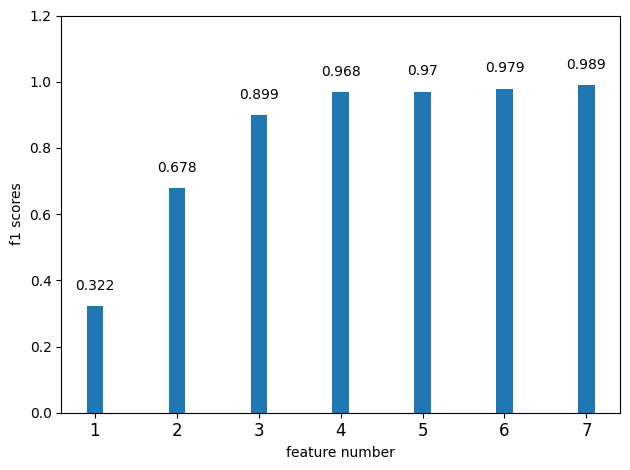

In [ ]:
fig, g=plt.subplots()
x=np.arange(1,8)
y=f1_sc_f
g.bar(x,y,width=0.2)
g.set_xlabel('feature number')
g.set_ylim(0,1.2)
g.set_ylabel('f1 scores')
g.set_xticks(np.arange(1,8))
g.set_xticklabels(np.arange(1,8),fontsize=12)
for i,v in enumerate(y):
  plt.text(x=i+1,y=v+0.05,s=str(v),ha='center')

plt.tight_layout()

Using chi2

In [ ]:
f1_score_chi2=[]

for k in range(1,8):
 selector_chi2=SelectKBest(chi2,k=k)
 selector_chi2.fit(x_train_c,y_train_c)
 x_train_chi2=selector.transform(x_train_c)
 x_test_chi2=selector.transform(x_test_c)

 svm_m.fit(x_train_chi2,y_train_c)
 y_pred_chi2=svm_m.predict(x_test_chi2)

 f1_score_chi2.append(round(f1_score(y_test_c,y_pred_chi2,average='weighted'),3))

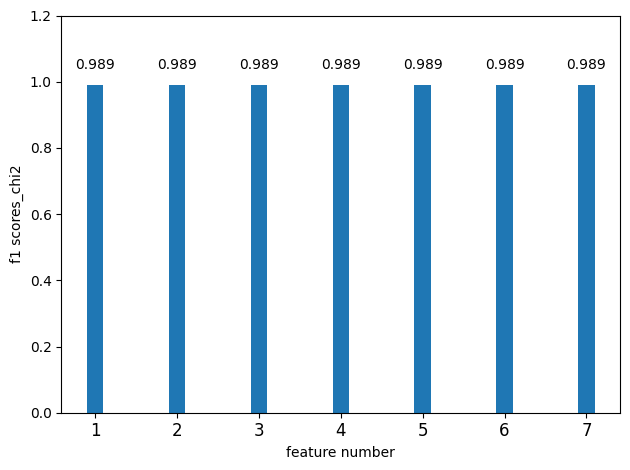

In [ ]:
ig, g=plt.subplots()
x=np.arange(1,8)
y=f1_score_chi2
g.bar(x,y,width=0.2)
g.set_xlabel('feature number')
g.set_ylim(0,1.2)
g.set_ylabel('f1 scores_chi2')
g.set_xticks(np.arange(1,8))
g.set_xticklabels(np.arange(1,8),fontsize=12)
for i,v in enumerate(y):
  plt.text(x=i+1,y=v+0.05,s=str(v),ha='center')

plt.tight_layout()

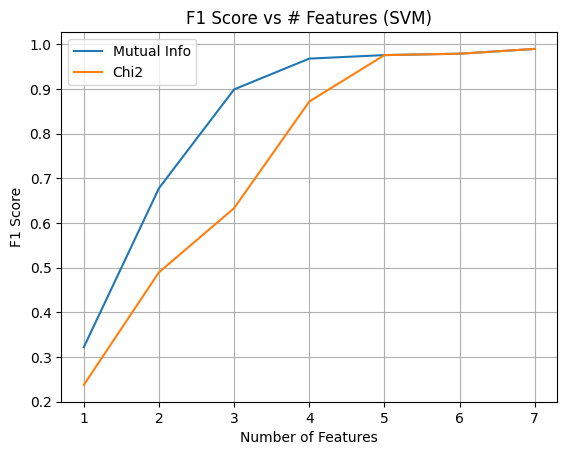

In [ ]:
f1_mi = []
f1_chi2 = []

for k in range(1, x_train_c.shape[1] + 1):
    # Mutual Info
    selector_mi = SelectKBest(score_func=mutual_info_classif, k=k)
    x_new_mi = selector_mi.fit_transform(x_train_c, y_train_c)
    svm_m.fit(x_new_mi, y_train_c)
    preds_mi = svm_m.predict(selector_mi.transform(x_test_c))
    f1_mi.append(f1_score(y_test_c, preds_mi, average='macro'))

    # Chi2
    selector_chi = SelectKBest(score_func=chi2, k=k)
    x_new_chi = selector_chi.fit_transform(x_train_c, y_train_c)
    svm_m.fit(x_new_chi, y_train_c)
    preds_chi = svm_m.predict(selector_chi.transform(x_test_c))
    f1_chi2.append(f1_score(y_test_c, preds_chi, average='macro'))

# Plot
plt.plot(range(1, x_train_c.shape[1]+1), f1_mi, label="Mutual Info")
plt.plot(range(1, x_train_c.shape[1]+1), f1_chi2, label="Chi2")
plt.xlabel("Number of Features")
plt.ylabel("F1 Score")
plt.title("F1 Score vs # Features (SVM)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
 selector_chi2=SelectKBest(chi2,k=1)
 selector_chi2.fit(x_train_c,y_train_c)
 x_train_chi2=selector.transform(x_train_c)
 x_test_chi2=selector.transform(x_test_c)

 svm_m.fit(x_train_chi2,y_train_c)
 y_pred_chi2=svm_m.predict(x_test_chi2)
 print(round(f1_score(y_pred_chi2,y_test_c,average='weighted'),3))

0.989


In [ ]:
print(classification_report(y_test_c,y_pred_chi2))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        30
      banana       1.00      1.00      1.00        30
   blackgram       1.00      1.00      1.00        30
    chickpea       1.00      1.00      1.00        30
     coconut       1.00      1.00      1.00        30
      coffee       1.00      1.00      1.00        30
      cotton       0.97      1.00      0.98        30
      grapes       1.00      1.00      1.00        30
        jute       0.86      1.00      0.92        30
 kidneybeans       0.97      1.00      0.98        30
      lentil       1.00      1.00      1.00        30
       maize       1.00      0.97      0.98        30
       mango       1.00      1.00      1.00        30
   mothbeans       1.00      1.00      1.00        30
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        30
      orange       1.00      1.00      1.00        30
      papaya       1.00    

In [ ]:
y_train_c.value_counts() ,y_test_c.value_counts()

(label
 lentil         70
 banana         70
 kidneybeans    70
 orange         70
 mango          70
 watermelon     70
 mungbean       70
 jute           70
 coconut        70
 rice           70
 blackgram      70
 papaya         70
 coffee         70
 pomegranate    70
 mothbeans      70
 cotton         70
 muskmelon      70
 maize          70
 apple          70
 grapes         70
 chickpea       70
 pigeonpeas     70
 Name: count, dtype: int64,
 label
 kidneybeans    30
 mothbeans      30
 blackgram      30
 jute           30
 papaya         30
 mango          30
 coffee         30
 maize          30
 rice           30
 coconut        30
 orange         30
 banana         30
 lentil         30
 chickpea       30
 cotton         30
 muskmelon      30
 pigeonpeas     30
 grapes         30
 mungbean       30
 pomegranate    30
 apple          30
 watermelon     30
 Name: count, dtype: int64)

In [ ]:
len(np.unique(Y))

22

# Calc complexitied for all models

In [ ]:

from sklearn.preprocessing import LabelEncoder
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(),
    'NaiveBayes': GaussianNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}


results = []

for name, model in models.items():
  max_accuracy = float('-inf')
  max_train_time = float('-inf')
  features_used=float('-inf')
  if name == 'XGBoost':
    le=LabelEncoder()
    y_train=le.fit_transform(y_train)
    y_test=le.transform(y_test)
  for i in range(1,8):
    start = time.time()
    selector=SelectKBest(mutual_info_classif,k=i)
    selector.fit(x_train,y_train)
    x_train_new=selector.transform(x_train_scaled)
    x_test_new=selector.transform(x_test_scaled)
    model.fit(x_train_new, y_train)
    train_time = time.time() - start


    y_pred = model.predict(x_test_new)
    accuracy = round(accuracy_score(y_test, y_pred),3)
    if accuracy>max_accuracy:
      max_accuracy=accuracy
      max_train_time=train_time
      features_used=i

  results.append([name, max_train_time, max_accuracy, features_used])


results_df = pd.DataFrame(results, columns=['Model', 'Train Time (s)', 'Accuracy', 'features_used'])
print(results_df)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.

                Model  Train Time (s)  Accuracy  features_used
0  LogisticRegression        0.597395     0.941              6
1                 KNN        0.201284     0.980              7
2        DecisionTree        0.194465     0.985              6
3        RandomForest        1.022882     0.995              6
4                 SVM        0.239453     0.989              7
5          NaiveBayes        0.196330     0.992              7
6             XGBoost        0.711664     0.989              7


Plot for above

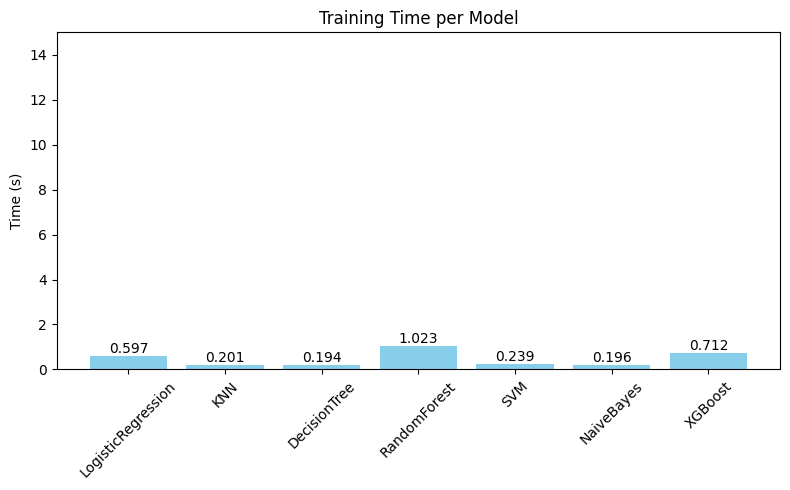

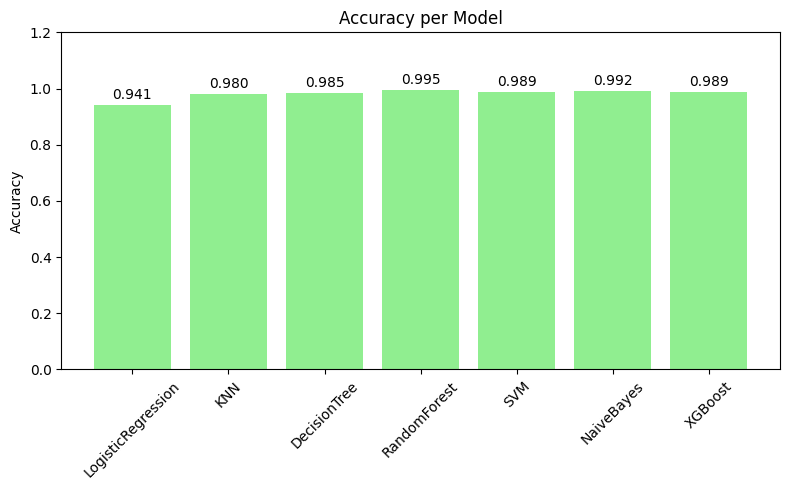

In [ ]:
import matplotlib.pyplot as plt

# Training Time Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Train Time (s)'], color='skyblue')
plt.title('Training Time per Model')
plt.ylim(0,15)
plt.ylabel('Time (s)')
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Accuracy Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color='lightgreen')
plt.title('Accuracy per Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.2)  # Set y-limit to 1.2
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


# Majority Voting classifier

In [5]:
!pip install -q memory_profiler


ERROR: Operation cancelled by user


In [6]:
import tracemalloc

In [7]:
y_train.head()

,label
864,lentil
1090,banana
304,kidneybeans
391,kidneybeans
1686,orange


In [22]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_train_encoded=le.fit_transform(y_train)
y_test_encoded=le.transform(y_test)

In [24]:

clf1 = LogisticRegression(max_iter=1000)
clf2 = KNeighborsClassifier()
clf3 = DecisionTreeClassifier()
clf4 = RandomForestClassifier(n_estimators=100)
clf5 = SVC(probability=True)
clf6 = GaussianNB()
clf7 = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')


voting_clf = VotingClassifier(
    estimators=[
        ('lr', clf1),
        ('knn', clf2),
        ('dt', clf3),
        ('rf', clf4),
        ('svm', clf5),
        ('nb', clf6),
        ('xgb', clf7)
    ],
    voting='hard')

selector=SelectKBest(mutual_info_classif,k=7)
selector.fit(x_train_scaled,y_train_encoded)
x_train_new=selector.transform(x_train_scaled)
x_test_new=selector.transform(x_test_scaled)

start = time.time()


voting_clf.fit(x_train_new, y_train_encoded)
voting_time = time.time() - start

y_pred_voting = voting_clf.predict(x_test_new)
voting_accuracy = round(accuracy_score(y_test_encoded, y_pred_voting),3)

mask=selector.get_support()
selected_features=features[mask]
print("features used:",selected_features)

print("Voting Classifier - Train Time:", voting_time)
print("Voting Classifier - Accuracy:", voting_accuracy)
print(classification_report(y_pred_voting,y_test_encoded))


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [11:58:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


features used: Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')
Voting Classifier - Train Time: 2.7232043743133545
Voting Classifier - Accuracy: 0.995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        30
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        30
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        30
           8       1.00      0.94      0.97        32
           9       1.00      1.00      1.00        30
          10       0.97      1.00      0.98        29
          11       1.00      1.00      1.00        30
          12       1.00      1.00      1.00        30
          13       1.00      0.97      0.98        31
   

In [32]:
y_test.unique()

array(['kidneybeans', 'mothbeans', 'blackgram', 'jute', 'papaya', 'mango',
       'coffee', 'maize', 'rice', 'coconut', 'orange', 'banana', 'lentil',
       'chickpea', 'cotton', 'muskmelon', 'pigeonpeas', 'grapes',
       'mungbean', 'pomegranate', 'apple', 'watermelon'], dtype=object)

In [17]:
y_test_encoded

array([ 9, 13,  2,  8,  8,  9, 17, 12,  5, 11, 20, 17,  4, 16, 12,  1, 10,
        3,  2,  6, 12, 15,  1,  9, 18, 17,  8, 12,  9,  7, 13,  8, 14, 19,
       13, 20,  9,  6,  2,  7, 13,  0,  4, 21,  6,  9, 11,  3, 16,  6, 12,
        9, 15, 10,  0,  1,  0, 11,  1,  4, 10,  3,  1, 18,  4, 20, 18, 17,
        5, 20, 16, 21,  5,  1,  3,  8, 15, 18, 11,  2,  7,  6,  7, 16,  3,
        2, 18, 20,  5,  4, 10, 21,  7,  7,  1,  7,  0, 19, 14, 17,  8,  1,
        5, 15, 18,  3,  7, 21, 19, 17, 16, 13, 19,  7,  8, 21, 12, 20,  6,
       13, 14, 18, 16,  7, 15, 12,  4,  6, 13,  3, 19, 19, 16,  9,  9, 20,
       14, 21, 18,  0, 11, 12, 16,  5, 17,  5,  8,  7, 12, 16,  8,  9, 15,
       19,  9, 10, 10, 17, 19,  9, 11, 10,  2,  4, 16, 15,  5,  9, 10, 21,
       20,  3,  7, 13,  0, 21, 21, 18, 14,  8,  5, 17, 11,  8,  8,  1, 13,
        3, 11,  4,  2, 18,  5, 17, 12, 21, 15, 15, 21, 15,  0,  2, 16, 13,
       21, 19,  4, 20, 15, 11,  9, 15, 14,  0, 11, 12,  9, 19, 13,  0,  7,
       21,  4,  6, 14, 10

In [ ]:
y_train_encoded=le.fit_tranform()

In [ ]:
import joblib
joblib.dump(voting_clf, "re_voting_model.pkl")

import os
size_mb = os.path.getsize("re_voting_model.pkl") / (1024 ** 2)
print(f"Model size on disk: {size_mb:.2f} MB")

Model size on disk: 5.53 MB


Plot for above

In [ ]:
data = {
    'N': [90],
    'P': [22],
    'K': [1],
    'temperature': [29],
    'humidity': [23],
    'ph': [10],
    'rainfall': [100]
}

df = pd.DataFrame(data)
df_scaled=sc.transform(df)
df_selected=selector.transform(df_scaled)
y_pred_voting = voting_clf.predict(df_selected)
print(y_pred_voting)

['coffee']


In [25]:
import joblib
joblib.dump(voting_clf, 'voting_clf.pkl')

['voting_clf.pkl']

In [26]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


In [27]:
joblib.dump(sc,'sc.pkl')
joblib.dump(selector,'selector.pkl')

['selector.pkl']

In [29]:

files.download('selector.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
files.download('sc.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files
files.download('voting_clf.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Soil type model inclusion


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving soil_data.pkl.gz to soil_data.pkl.gz


In [ ]:
import gzip,pickle
with gzip.open(r"C:\Users\Lenovo\Downloads\data_agri\soil_data.pkl.gz", "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)


In [ ]:
from tensorflow.keras import datasets,models,layers, optimizers
import tensorflow as tf
import time
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
def plot_accuracy(history):

   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Accuracy plot
   ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
   ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
   ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
   ax1.set_xlabel('Epoch')
   ax1.set_ylabel('Accuracy')
   ax1.legend()
   ax1.grid(True, alpha=0.3)

        # Loss plot
   ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
   ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
   ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
   ax2.set_xlabel('Epoch')
   ax2.set_ylabel('Loss')
   ax2.legend()
   ax2.grid(True, alpha=0.3)

   plt.tight_layout()
   plt.show()

In [ ]:
def preprocess_data(X, y, batch_size):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',      # Watch validation loss
    patience=5,              # Stop if no improvement for 5 epochs
    restore_best_weights=True,  # Roll back to best model
    verbose=1                # Print when it stops
)

In [ ]:
def train_model(x_train,y_train,epoch,batch_size,lr,num,drop):
  cnn=models.Sequential([
    layers.Conv2D(filters=64,kernel_size=3, activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(filters=64,kernel_size=3, activation='relu',padding='same'),
    layers.Dropout(drop),
    layers.MaxPooling2D(),

    layers.Conv2D(filters=128,kernel_size=3, activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(filters=128,kernel_size=3, activation='relu',padding='same'),
    layers.Dropout(drop),
    layers.MaxPooling2D(),


    layers.Conv2D(filters=256,kernel_size=3, activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Dropout(drop),

    layers.GlobalAveragePooling2D(),
    layers.Flatten(),
    layers.Dense(num, activation='relu'),
    layers.BatchNormalization(),
     layers.Dropout(drop),
    layers.Dense(num, activation='relu'),
     layers.Dropout(drop),
    layers.Dense(5, activation='softmax'),

   ])

  cnn.compile(optimizer=optimizers.Adam(learning_rate=lr),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  train_ds = preprocess_data(x_train, y_train, batch_size)
  val_ds = preprocess_data(X_test, y_test, batch_size)

  history = cnn.fit(train_ds, validation_data=val_ds, epochs=epoch,class_weight=class_weights, verbose=1)

  return history,cnn

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 333ms/step - accuracy: 0.5894 - loss: 1.0196 - val_accuracy: 0.4312 - val_loss: 1.4670
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 306ms/step - accuracy: 0.7387 - loss: 0.6309 - val_accuracy: 0.3871 - val_loss: 1.5617
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 303ms/step - accuracy: 0.7888 - loss: 0.5321 - val_accuracy: 0.3669 - val_loss: 2.6000
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 304ms/step - accuracy: 0.8358 - loss: 0.4254 - val_accuracy: 0.4200 - val_loss: 2.3811
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 310ms/step - accuracy: 0.8494 - loss: 0.3856 - val_accuracy: 0.5288 - val_loss: 2.0483
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 305ms/step - accuracy: 0.8438 - loss: 0.3898 - val_accuracy: 0.5941 - val_loss: 1.6239
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 302ms/step - accuracy: 0.8699 - loss: 0.3392 - val_accuracy: 0.5450 - val_loss: 1.5645
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 303ms/step - accuracy: 0.8806 - loss: 0.3300 - 

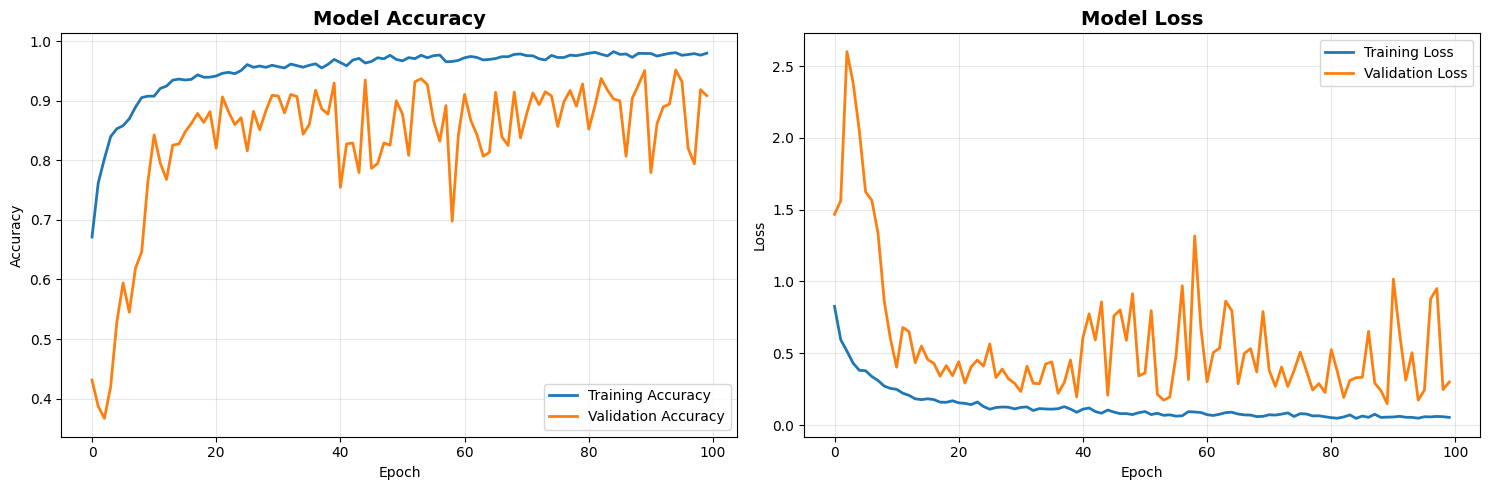

In [ ]:
start = time.time()
history,cnn=train_model(X_train,y_train,40,64,0.0005,64,0.2)
train_time = time.time() - start
val_loss=cnn.evaluate(X_test,y_test)[0]

  #history= least_loss_model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),batch_size=best_batch_size,verbose=0)
y_best= cnn.predict(X_test)
y_best_classes=np.argmax(y_best,axis=1)
print(classification_report(y_test,y_best_classes))
print(round(f1_score(y_test,y_best_classes,average='weighted'),3))
print(val_loss)
print(train_time)
plot_accuracy(history)


with open("soil_classif.pkl","wb") as f:
    pickle.dump((cnn,history),f)

Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 327ms/step - accuracy: 0.5636 - loss: 1.0971 - val_accuracy: 0.3937 - val_loss: 1.4830
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 306ms/step - accuracy: 0.7381 - loss: 0.6725 - val_accuracy: 0.3760 - val_loss: 1.5029
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 303ms/step - accuracy: 0.7866 - loss: 0.5503 - val_accuracy: 0.3704 - val_loss: 2.0735
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 303ms/step - accuracy: 0.8186 - loss: 0.4778 - val_accuracy: 0.3790 - val_loss: 1.9957
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 305ms/step - accuracy: 0.8319 - loss: 0.4303 - val_accuracy: 0.4160 - val_loss: 2.1681
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 309ms/step - accuracy: 0.8716 - loss: 0.3510 - val_accuracy: 0.5491 - val_loss: 1.8784
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 305ms/step - accuracy: 0.8730 - loss: 0.3444 - val_accuracy: 0.6007 - val_loss: 1.3833
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 302ms/step - accuracy: 0.9045 - loss: 0.2641 - val_accu

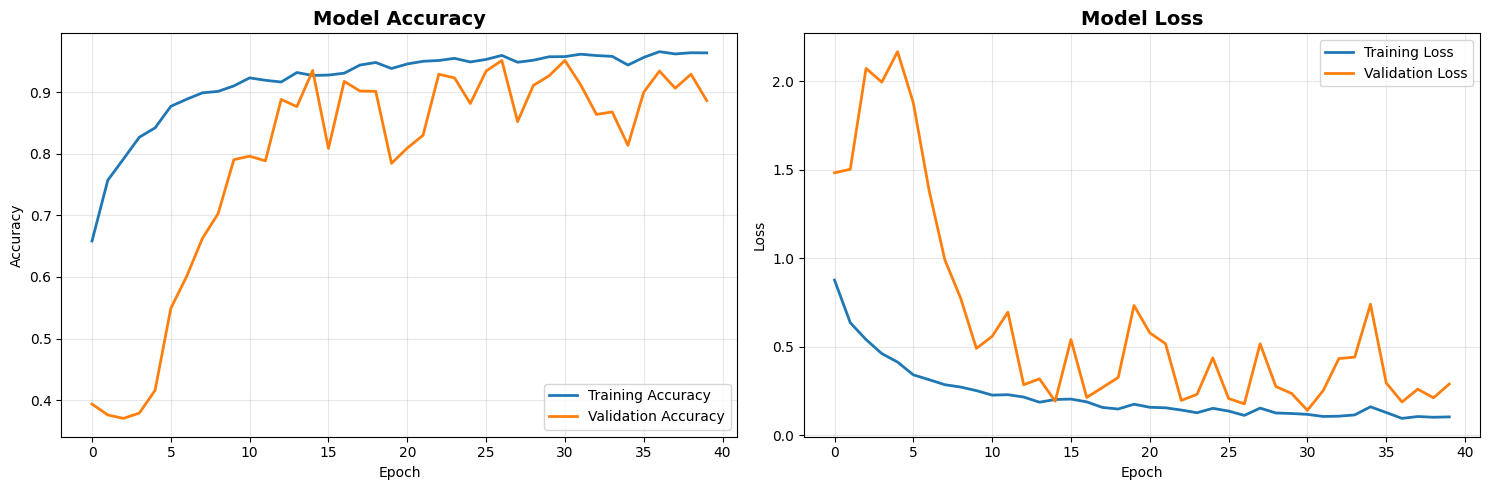

In [ ]:
start = time.time()
history,cnn=train_model(X_train,y_train,40,64,0.0005,64,0.2)
train_time = time.time() - start
val_loss=cnn.evaluate(X_test,y_test)[0]

  #history= least_loss_model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),batch_size=best_batch_size,verbose=0)
y_best= cnn.predict(X_test)
y_best_classes=np.argmax(y_best,axis=1)
print(classification_report(y_test,y_best_classes))
print(round(f1_score(y_test,y_best_classes,average='weighted'),3))
print(val_loss)
print(train_time)
plot_accuracy(history)


with open("soil_classif.pkl","wb") as f:
    pickle.dump((cnn,history),f)

Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 331ms/step - accuracy: 0.6026 - loss: 0.9478 - val_accuracy: 0.3679 - val_loss: 1.4898
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 303ms/step - accuracy: 0.7534 - loss: 0.5619 - val_accuracy: 0.3664 - val_loss: 1.6778
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 304ms/step - accuracy: 0.7856 - loss: 0.5135 - val_accuracy: 0.3664 - val_loss: 3.0360
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 305ms/step - accuracy: 0.8328 - loss: 0.4336 - val_accuracy: 0.3669 - val_loss: 2.8511
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 303ms/step - accuracy: 0.8591 - loss: 0.3472 - val_accuracy: 0.5344 - val_loss: 2.1643
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 22s 306ms/step - accuracy: 0.8862 - loss: 0.2912 - val_accuracy: 0.5901 - val_loss: 1.5694
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 302ms/step - accuracy: 0.8856 - loss: 0.2875 - val_accuracy: 0.5896 - val_loss: 1.5014
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 307ms/step - accuracy: 0.8834 - loss: 0.2756 - val_accu

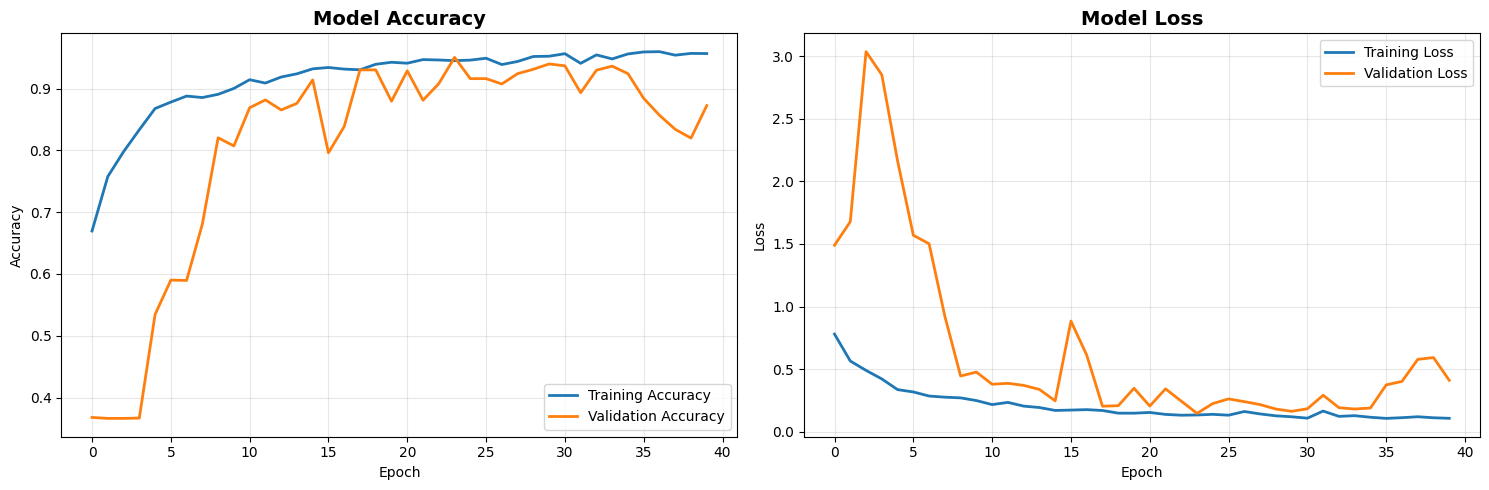

In [ ]:
start = time.time()
history,cnn=train_model(X_train,y_train,40,64,0.0005,64,0.15)
train_time = time.time() - start
val_loss=cnn.evaluate(X_test,y_test)[0]

  #history= least_loss_model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),batch_size=best_batch_size,verbose=0)
y_best= cnn.predict(X_test)
y_best_classes=np.argmax(y_best,axis=1)
print(classification_report(y_test,y_best_classes))
print(round(f1_score(y_test,y_best_classes,average='weighted'),3))
print(val_loss)
print(train_time)
plot_accuracy(history)


with open("soil_classif.pkl","wb") as f:
    pickle.dump((cnn,history),f)

In [ ]:
start = time.time()
history,cnn=train_model(X_train,y_train,30,64,0.0005,32,0.2)
train_time = time.time() - start
val_loss=cnn.evaluate(X_test,y_test)[0]

  #history= least_loss_model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),batch_size=best_batch_size,verbose=0)
y_best= cnn.predict(X_test)
y_best_classes=np.argmax(y_best,axis=1)
print(classification_report(y_test,y_best_classes))
print(round(f1_score(y_test,y_best_classes,average='weighted'),3))
print(val_loss)
print(train_time)
plot_accuracy(history)


with open("soil_classif.pkl","wb") as f:
    pickle.dump((cnn,history),f)

Epoch 1/30
17/72 ━━━━━━━━━━━━━━━━━━━━ 2:25 3s/step - accuracy: 0.4440 - loss: 1.4797

KeyboardInterrupt: 

# Using tree models

# CNN model


In [ ]:
df_features = df.drop('label', axis=1)
df_target=df['label']

X=df_features.values
Y=df_target.values

Some preprocessssing of data

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
sc=StandardScaler()
le=LabelEncoder()
X_scaled=sc.fit_transform(X)
y_encoded=le.fit_transform(Y)

X_re=X_scaled.reshape(X_scaled.shape[0],X_scaled.shape[1],1)

Splitting of data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
x_train,x_test,y_train,y_test=train_test_split(X_re,y_encoded,test_size=0.3,random_state=42,stratify=y_encoded)

In [ ]:
from tensorflow.keras import datasets,models,layers

Model

In [ ]:
cnn=models.Sequential([
    layers.Conv1D(filters=64,kernel_size=3, activation='relu',padding='same',input_shape=(X_re.shape[1], 1)),
    layers.BatchNormalization(),
    layers.Conv1D(filters=64,kernel_size=3, activation='relu',padding='same'),
    layers.Dropout(0.5),
    layers.MaxPooling1D(pool_size=2),

     layers.Conv1D(filters=128,kernel_size=3, activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Conv1D(filters=128,kernel_size=3, activation='relu',padding='same'),
    layers.Dropout(0.4),
    layers.MaxPooling1D(pool_size=2),


    layers.Conv1D(filters=256,kernel_size=3, activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling1D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
     layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
     layers.Dropout(0.5),
    layers.Dense(22, activation='softmax'),

])

cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history=cnn.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test),batch_size=32,verbose=0)

In [ ]:
cnn.evaluate(x_test,y_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9704 - loss: 0.1028


[0.0766976848244667, 0.978787899017334]

In [ ]:
y_pred=cnn.predict(x_test)
y_pred_classes=np.argmax(y_pred,axis=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        30
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        30
           6       0.88      1.00      0.94        30
           7       1.00      1.00      1.00        30
           8       0.86      1.00      0.92        30
           9       0.97      1.00      0.98        30
          10       1.00      0.97      0.98        30
          11       1.00      0.87      0.93        30
          12       0.94      1.00      0.97        30
          13       0.93      0.93      0.93        30
          14       1.00      1.00      1.00        30
          15       1.00      1.00      1.00        30
          16       1.00      1.00      1.00        30
          17       1.00    

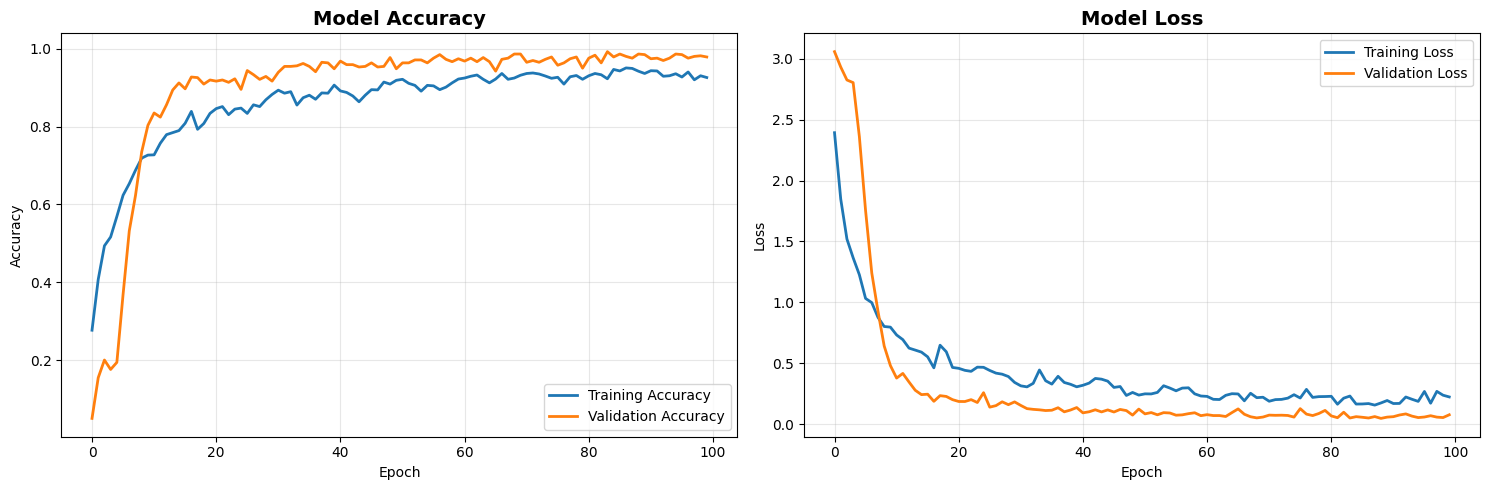

In [ ]:
print(classification_report(y_test,y_pred_classes))
print(cnn.evaluate(x_test,y_test)[0])
print(round(f1_score(y_test,y_pred_classes,average='weighted'),3))
plot_accuracy(history)

In [ ]:
from tensorflow.keras import optimizers
def train_model(x_train,y_train,epoch,batch_size,lr,num,drop):
  cnn=models.Sequential([
    layers.Conv1D(filters=64,kernel_size=3, activation='relu',padding='same',input_shape=(X_re.shape[1], 1)),
    layers.BatchNormalization(),
    layers.Conv1D(filters=64,kernel_size=3, activation='relu',padding='same'),
    layers.Dropout(drop),
    layers.MaxPooling1D(pool_size=2),

     layers.Conv1D(filters=128,kernel_size=3, activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Conv1D(filters=128,kernel_size=3, activation='relu',padding='same'),
    layers.Dropout(drop),
    layers.MaxPooling1D(pool_size=2),


    layers.Conv1D(filters=256,kernel_size=3, activation='relu',padding='same'),
    layers.BatchNormalization(),
    layers.Dropout(drop),

    layers.GlobalAveragePooling1D(),
    layers.Flatten(),
    layers.Dense(num, activation='relu'),
    layers.BatchNormalization(),
     layers.Dropout(drop),
    layers.Dense(num, activation='relu'),
     layers.Dropout(drop),
    layers.Dense(22, activation='softmax'),

   ])

  cnn.compile(optimizer=optimizers.Adam(learning_rate=lr),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
  history= cnn.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test),batch_size=32,verbose=0)

  return history,cnn


In [ ]:
def plot_accuracy(history):

   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Accuracy plot
   ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
   ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
   ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
   ax1.set_xlabel('Epoch')
   ax1.set_ylabel('Accuracy')
   ax1.legend()
   ax1.grid(True, alpha=0.3)

        # Loss plot
   ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
   ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
   ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
   ax2.set_xlabel('Epoch')
   ax2.set_ylabel('Loss')
   ax2.legend()
   ax2.grid(True, alpha=0.3)

   plt.tight_layout()
   plt.show()

In [ ]:
epoch=100
least_val_loss=float('inf')
least_loss_model=None
for drop in[0,0.5]:
  for batch_size in [32,64,128]:
    for lr in [0.001,0.0001,0.005]:
      for num in [128,256,512]:
        history,cnn=train_model(x_train,y_train,epoch,batch_size,lr,num,drop)
        val_loss=cnn.evaluate(x_test,y_test)[0]
        if val_loss<least_val_loss:
          least_val_loss=val_loss
          least_loss_model=cnn


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9868 - loss: 0.0371
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9694 - loss: 0.1048
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9355 - loss: 0.5161
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9878 - loss: 0.0476
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9714 - loss: 0.0981
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9773 - loss: 0.0693
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9654 - loss: 0.3080
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9799 - loss: 0.0403
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9691 - loss: 0.0744
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9824 - loss: 0.0585
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9872 - loss: 0.0387
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9801 - loss: 0.0547
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9785 - loss: 0.0601
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        30
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        30
           6       0.97      1.00      0.98        30
           7       1.00      1.00      1.00        30
           8       0.91      1.00      0.95        30
           9       0.97      1.00      0.98        30
          10       1.00      0.97      0.98        30
          11       1.00      0.97      0.98        30
          12       1.00      1.00      1.00        30
          13       0.97      0.97      0.97        30
          14       1.00      1.00      1.00        30
          15       1.00      1.00      1.00        30
          16       1.00      1.00      1.0

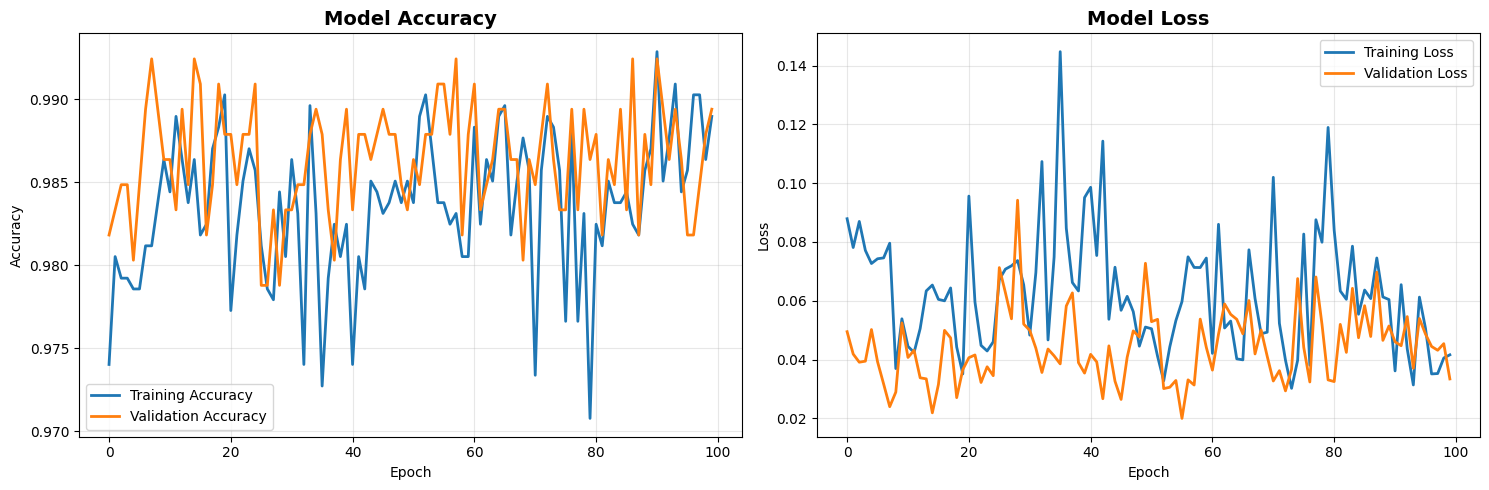

In [ ]:
history= least_loss_model.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test),batch_size=32,verbose=0)
y_best= least_loss_model.predict(x_test)
y_best_classes=np.argmax(y_best,axis=1)
print(classification_report(y_test,y_best_classes))
print(round(f1_score(y_test,y_best_classes,average='weighted'),3))
print(least_val_loss)
plot_accuracy(history)

### Using WHALE OPTIMIZATION ALGO

In [ ]:
!pip install -U mealpy

In [ ]:
from mealpy.swarm_based.WOA import OriginalWOA
from mealpy.utils.problem import Problem
from mealpy.utils.space import FloatVar, IntegerVar

# ✅ Dummy fitness function
def obj_function(solution):
    filters, kernel_size, dropout, dense_units, lr = solution
    # Just an example function: closer to ideal → lower value
    return (filters - 64)**2 + (kernel_size - 3)**2 + (dropout - 0.3)**2 + (dense_units - 128)**2 + (lr - 0.001)**2

# ✅ Define problem bounds using FloatVar / IntegerVar
bounds = [
    IntegerVar(16, 128),        # filters
    IntegerVar(3, 5),           # kernel size
    FloatVar(0.1, 0.5),         # dropout
    IntegerVar(32, 512),        # dense units
    FloatVar(1e-4, 1e-2)        # learning rate
]

# ✅ Define the problem correctly with bounds=
problem = Problem(
    fit_func=obj_function,
    bounds=bounds,
    minmax="min"
)

# ✅ Use OriginalWOA, NOT BaseWOA
model = OriginalWOA(epoch=10, pop_size=10)
best = model.solve(problem)

print("Best solution:", best.solution)
print("Best fitness:", best.loss)


INFO:mealpy.swarm_based.WOA.OriginalWOA:OriginalWOA(epoch=10, pop_size=10)


NotImplementedError: 

# Linear Regression

In [ ]:
df=pd.read_csv("hiring.csv")

In [ ]:
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [ ]:
!pip install word2number
from word2number import w2n

In [ ]:

df['experience']=df['experience'].fillna("zero")

df['experience'] = df['experience'].apply(w2n.word_to_num)

In [ ]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,7.0,7,72000
7,11,7.0,8,80000


In [ ]:
import math
print(math.floor(df['test_score(out of 10)'].mean()))
df['test_score(out of 10)']=df['test_score(out of 10)'].fillna(math.floor(df['test_score(out of 10)'].mean()))
df['interview_score(out of 10)']=df['interview_score(out of 10)'].fillna(math.floor(df['interview_score(out of 10)'].mean()))

7


In [ ]:
df.head(100)

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,7.0,7,72000
7,11,7.0,8,80000


In [ ]:
X=df.drop('salary($)',axis=1)
Y=df['salary($)']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_testt=train_test_split(X,Y,test_size=0.3,random_state=42)

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import f1_score

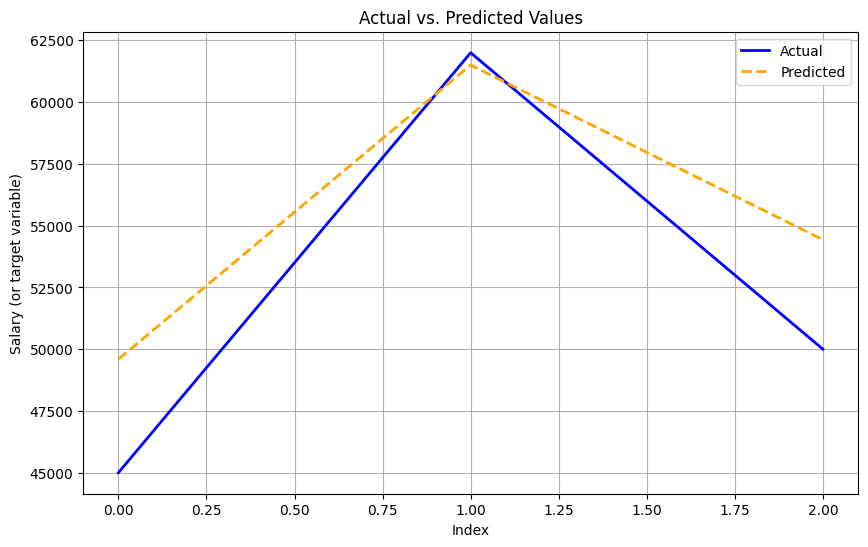

In [ ]:
import matplotlib.pyplot as plt

# Optional: use index or range if no x-axis values exist
x = range(len(y_test))

plt.figure(figsize=(10, 6))
plt.plot(x, y_test, label='Actual', color='blue', linewidth=2)
plt.plot(x, y_pred, label='Predicted', color='orange', linewidth=2, linestyle='--')

plt.xlabel("Index")
plt.ylabel("Salary (or target variable)")
plt.title("Actual vs. Predicted Values")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 3175.034867503486
MSE: 13668675.56006839
R² Score: 0.7314015719637216


In [ ]:
model.predict([[11,7,8]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([78443.51464435])

In [ ]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


# New dataset on housing

In [ ]:
df=pd.read_csv("housing.csv")

In [ ]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
0,9136
1,6551
4,2658
3,2290
2,5


In [ ]:
import math

df=df.fillna(df.median())

In [ ]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder();
df['ocean_proximity']=lb.fit_transform(df['ocean_proximity'])

In [ ]:
df['log_price'] = np.log1p(df['median_house_value'])

In [ ]:
df


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,log_price
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3,13.022766
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3,12.789687
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3,12.771673
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3,12.740520
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3,12.743154
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,11.265758
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,11.252872
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,11.432810
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,11.346883


In [ ]:
X=df.drop(['median_house_value','log_price'],axis=1)
Y=df['log_price']

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_scaled,Y,test_size=0.3,random_state=42)

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_test)

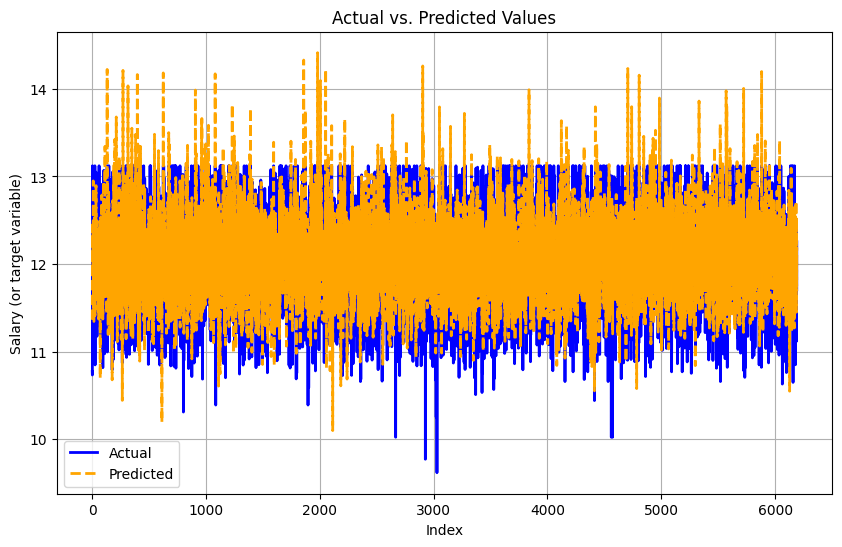

In [ ]:
import matplotlib.pyplot as plt

# Optional: use index or range if no x-axis values exist
x = range(len(y_test))

plt.figure(figsize=(10, 6))
plt.plot(x, y_test, label='Actual', color='blue', linewidth=2)
plt.plot(x, y_pred, label='Predicted', color='orange', linewidth=2, linestyle='--')

plt.xlabel("Index")
plt.ylabel("Salary (or target variable)")
plt.title("Actual vs. Predicted Values")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test_actual, y_pred_actual))
print("MSE:", mean_squared_error(y_test_actual, y_pred_actual))
print("R² Score:", r2_score(y_test_actual, y_pred_actual))

MAE: 52433.00753827869
MSE: 8190778105.104835
R² Score: 0.37595978543107433


In [ ]:
# Convert predicted log(price) back to original scale
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)


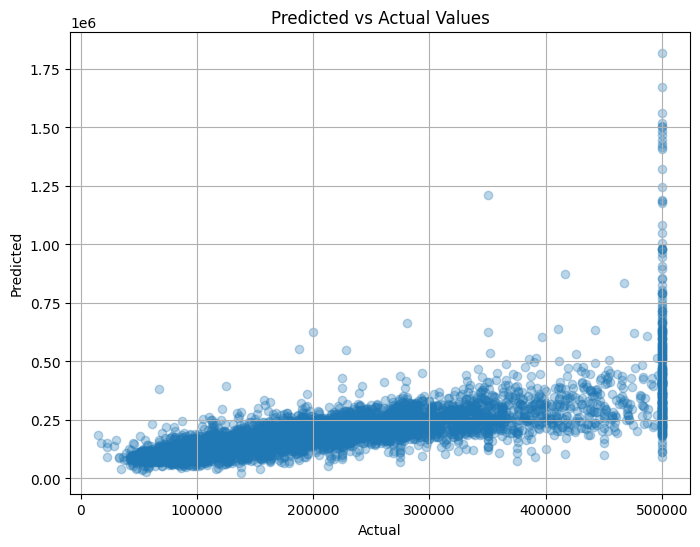

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Values")
plt.grid(True)
plt.show()


In [ ]:
print(df['median_house_value'].describe())
print(df['median_house_value'].value_counts().sort_values(ascending=False).head(10))


count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64
median_house_value
500001.0    965
137500.0    122
162500.0    117
112500.0    103
187500.0     93
225000.0     92
350000.0     79
87500.0      78
275000.0     65
150000.0     64
Name: count, dtype: int64


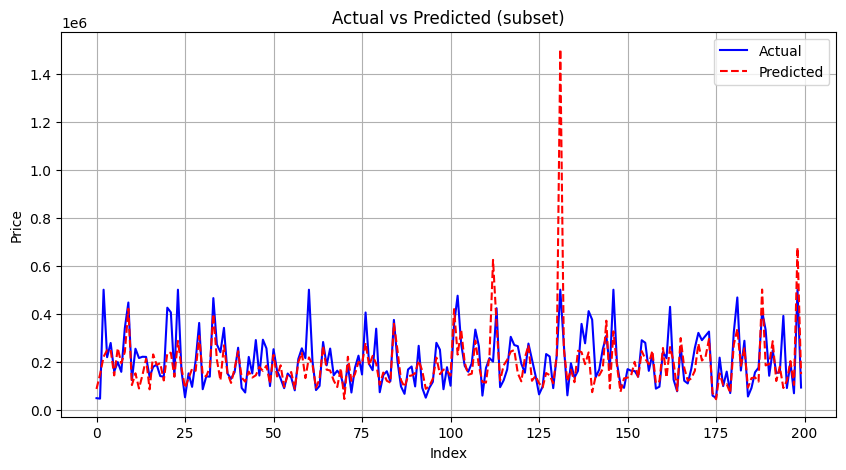

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test_actual[:200].values, label="Actual", color="blue")
plt.plot(y_pred_actual[:200], label="Predicted", color="red", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted (subset)")
plt.legend()
plt.grid(True)
plt.show()
